In [7]:
import numpy as np


In [ ]:
pip install matplotlib

In [149]:
import matplotlib.pyplot as plt

In [206]:
# Linear Regression using Normal Equation
plt.figure(figsize=(8,4))
class LinearRegression:
    
    def __init__(self, lr=0.05, epochs=1000):
        self.X= None
        self.y = None
        self.lr = lr
        self.epochs = epochs
        self.W = None
        self.b = None
    
    def _initialize_parameters(self,n_features):
        self.W = np.random.randn(n_features,1) * 0.01
        self.b = np.zeros((1,1))

    def _forward(self, X):
        return X @ self.W + self.b

    def _loss(self, y, y_hat):
        return np.mean((y_hat - y) ** 2)

    def _backward(self, X, y, y_hat):
        n = X.shape[0]
        error = y_hat - y
        
        dW = (2/n) * (X.T @ error)
        db = (2/n) * np.sum(error)
        
        return dW, db
    

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        
        for epoch in range(self.epochs):
            # 1. Calcutate the output on first pass y_hat
            y_hat = self._forward(X)

            # 2. Calculate the loss for pass on W and B
            loss = self._loss(y, y_hat)
            
            # 
            # 3. Calculate the gradients for W and B
            dW, db = self._backward(X, y, y_hat)
            
            # 4. Update the parameters W and B according to backword pass
            self.W -= self.lr * dW
            self.b -= self.lr * db
            if epoch % 20 == 0:
                # Create a small, right-aligned animation window (skip window placement for compatibility)
                fig, ax = plt.subplots(figsize=(3, 2))
                # The following line is removed for compatibility:
                # fig.canvas.manager.window.wm_geometry("+1200+100")

                # Sort for line plot
                sorted_idx = np.argsort(X[:, 0])
                X_sorted = X[sorted_idx]
                y_sorted = y_hat[sorted_idx]

                ax.scatter(X[:, 0], y, s=10, color='blue', label='Actual')
                ax.plot(X_sorted, y_sorted, color='red', label='Prediction')
                ax.set_title(f"Epoch {epoch}", fontsize=8)
                ax.set_xlabel("X", fontsize=8)
                ax.set_ylabel("y", fontsize=8)
                ax.legend(fontsize=6)
                plt.tight_layout()
                plt.pause(0.1)
                plt.close(fig)
                print(f"Epoch {epoch}, Loss: {loss}")
    def predict(self, X):
        return self._forward(X)


<Figure size 800x400 with 0 Axes>

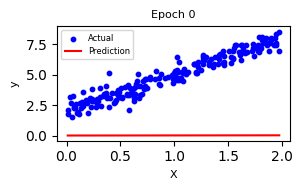

Epoch 0, Loss: 27.589730851052078


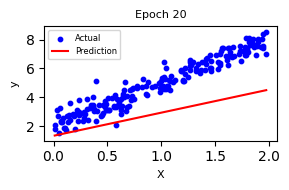

Epoch 20, Loss: 5.0866509233250925


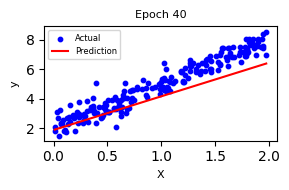

Epoch 40, Loss: 1.1066611383809337


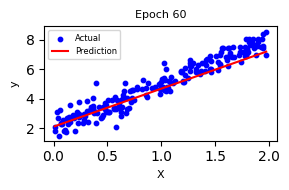

Epoch 60, Loss: 0.4012443739206821


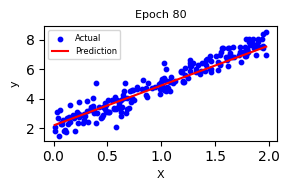

Epoch 80, Loss: 0.27490127534562425


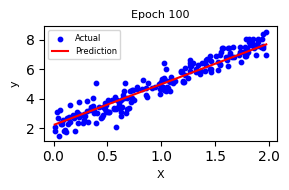

Epoch 100, Loss: 0.2511225217342373


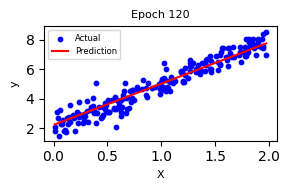

Epoch 120, Loss: 0.245651202301077


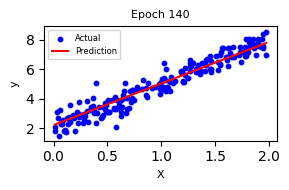

Epoch 140, Loss: 0.24357156294977098


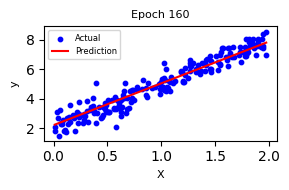

Epoch 160, Loss: 0.24222789094370353


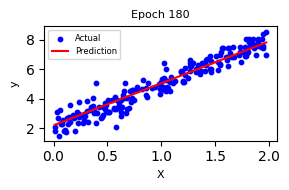

Epoch 180, Loss: 0.24113400872604743
Training completed. Final Loss: 0.24018929713206652
Final Weight: [[2.84722411]]
Final Bias: [[2.20581832]]


In [209]:
import numpy as np
import matplotlib.pyplot as plt

# Create dataset
np.random.seed(42)

X = 2 * np.random.rand(200, 1)
y = 3 * X + 2 + np.random.randn(200, 1) * 0.5  # add noise

# Create and train model
model = LinearRegression(lr=0.01, epochs=200)
model.fit(X, y)
print(f"Training completed. Final Loss: {model._loss(y, model.predict(X))}")
# Predictions
y_pred = model.predict(X)


print("Final Weight:", model.W)
print("Final Bias:", model.b)


In [142]:
# predict the output for the test data
y_pred = model.predict(np.random.randn(200, 2))


In [143]:
y.shape, y_pred.shape

((200, 1), (200, 1))

Text(0, 0.5, 'Target')

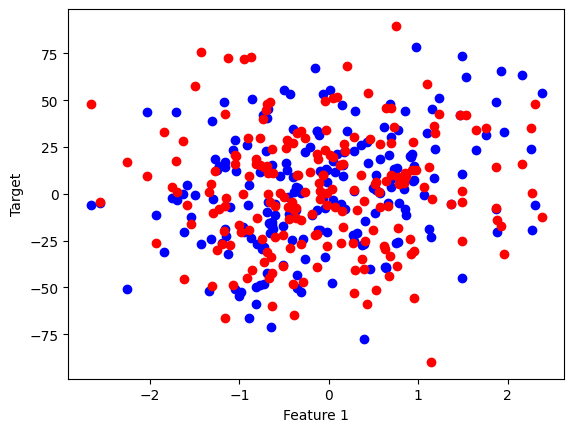

In [144]:
from matplotlib import pyplot as plt
plt.scatter(X[:,0], y, color='blue', label='Actual')
plt.scatter(X[:,0], y_pred, color='red', label='Predicted')
plt.xlabel('Feature 1')
plt.ylabel('Target')